In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [4]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1000
Number of Columns: 17


In [6]:
print("Columns in Dataset:")
print(df.columns.tolist())

Columns in Dataset:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [8]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully")
print("New Shape:", df.shape)

Duplicates Removed Successfully
New Shape: (1000, 17)


In [10]:
print(df.dtypes)

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


In [11]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].dtype)

datetime64[us]


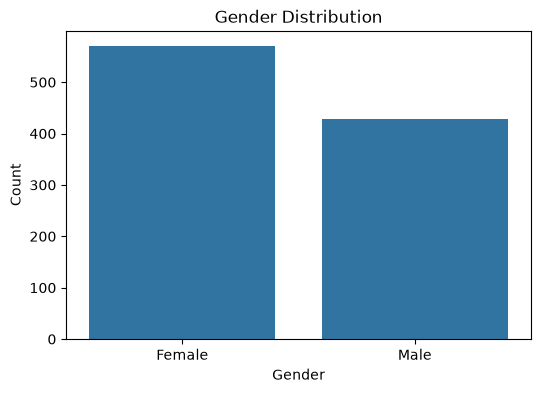

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

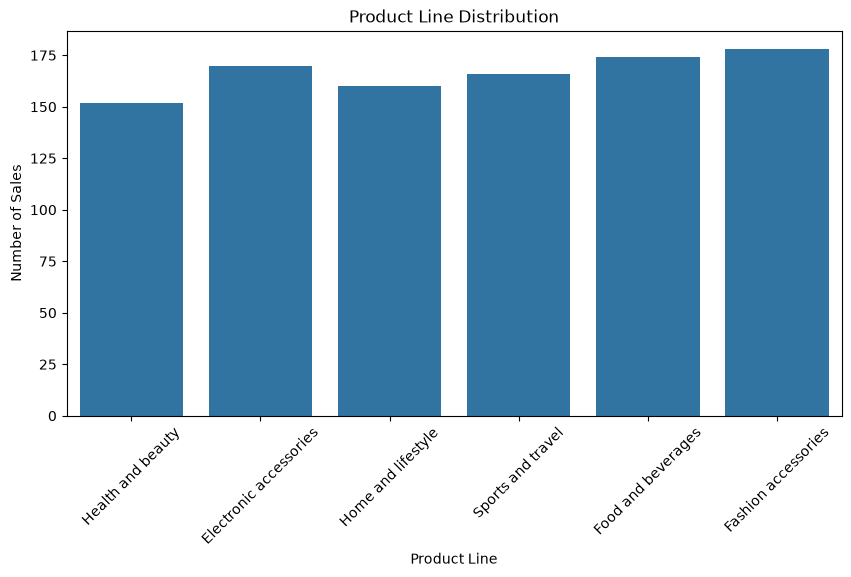

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Product line")

plt.title("Product Line Distribution")
plt.xlabel("Product Line")
plt.ylabel("Number of Sales")

plt.xticks(rotation=45)

plt.show()

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


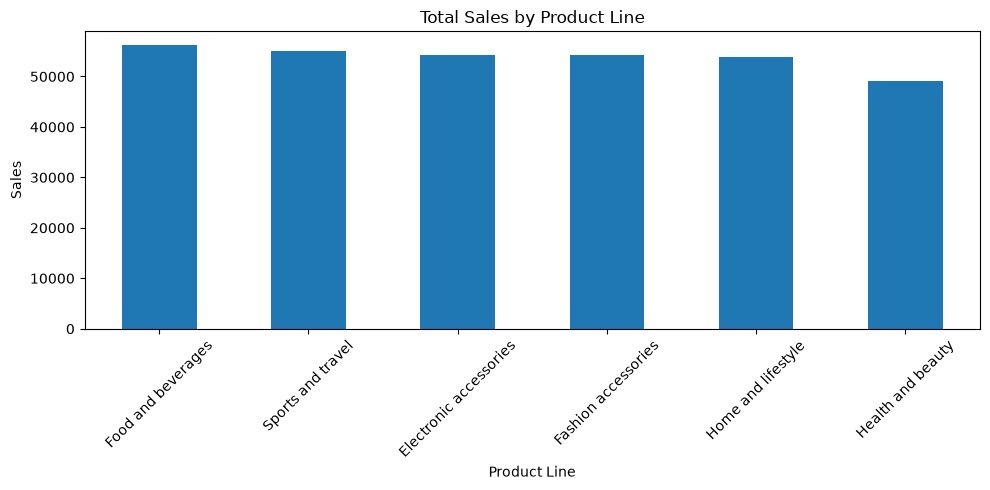

In [20]:
sales_by_product = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

print(sales_by_product)

plt.figure(figsize=(10, 5))

sales_by_product.plot(kind="bar")

plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


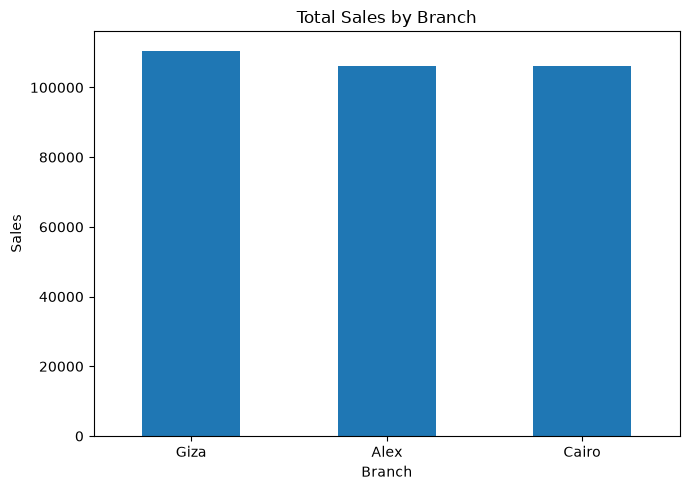

In [21]:
sales_by_branch = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

print(sales_by_branch)

plt.figure(figsize=(7, 5))

sales_by_branch.plot(kind="bar")

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64


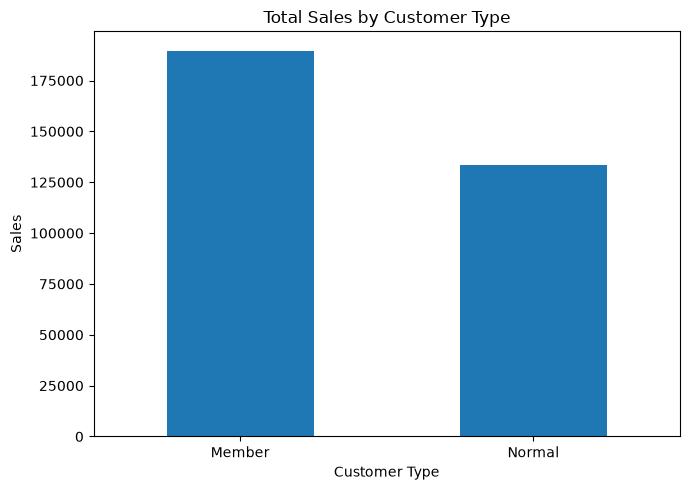

In [22]:
sales_by_customer = df.groupby("Customer type")["Sales"].sum().sort_values(ascending=False)

print(sales_by_customer)

plt.figure(figsize=(7, 5))

sales_by_customer.plot(kind="bar")

plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


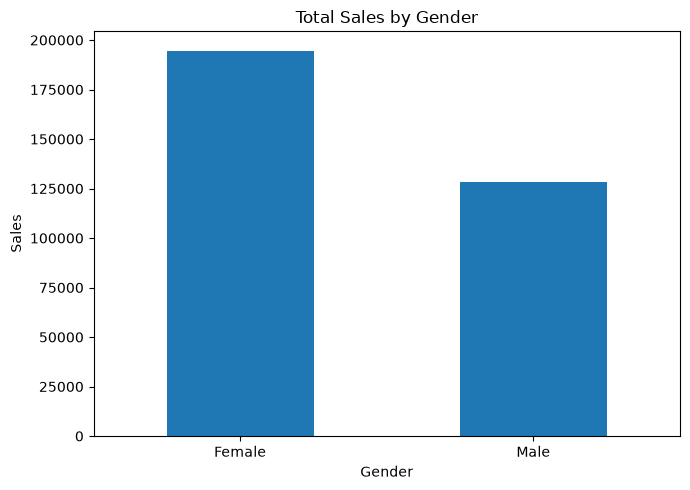

In [23]:
sales_by_gender = df.groupby("Gender")["Sales"].sum().sort_values(ascending=False)

print(sales_by_gender)

plt.figure(figsize=(7, 5))

sales_by_gender.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Sales, dtype: float64


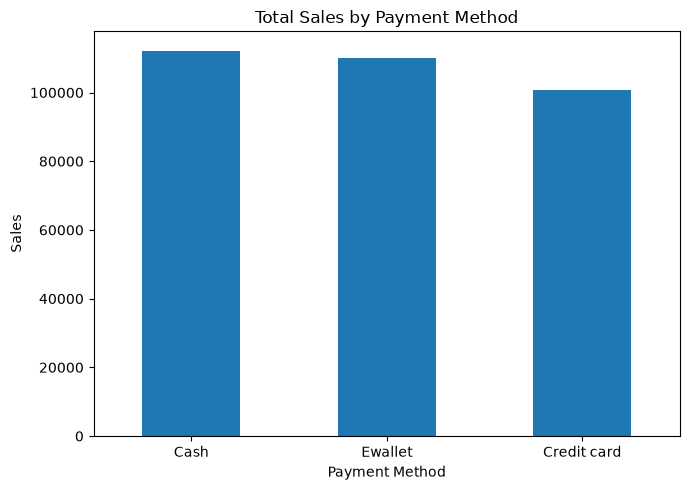

In [24]:
sales_by_payment = df.groupby("Payment")["Sales"].sum().sort_values(ascending=False)

print(sales_by_payment)

plt.figure(figsize=(7, 5))

sales_by_payment.plot(kind="bar")

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


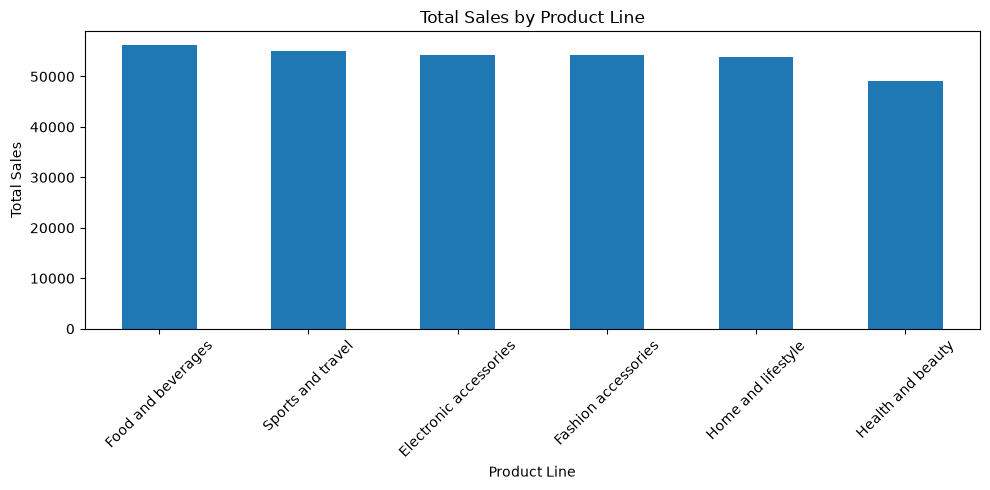

In [25]:
sales_by_product = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

print(sales_by_product)

plt.figure(figsize=(10, 5))

sales_by_product.plot(kind="bar")

plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64


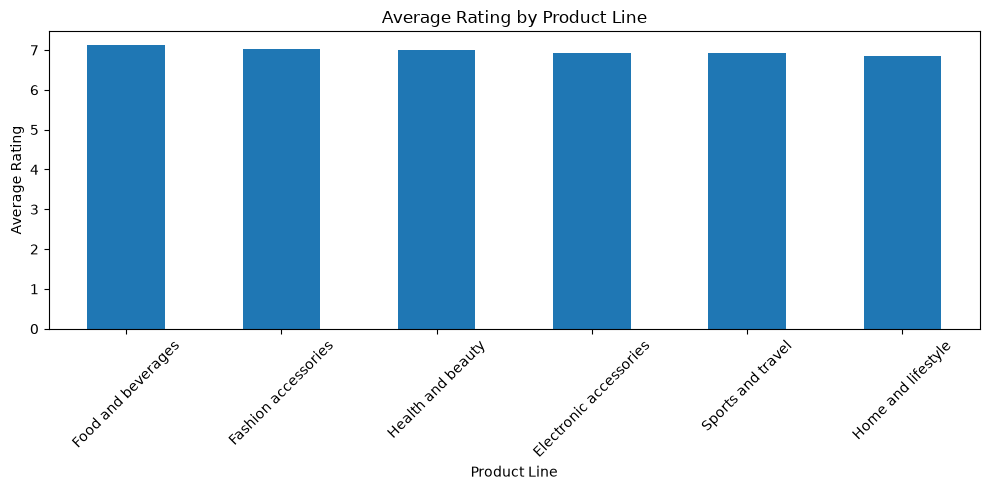

In [26]:
rating_by_product = df.groupby("Product line")["Rating"].mean().sort_values(ascending=False)

print(rating_by_product)

plt.figure(figsize=(10, 5))

rating_by_product.plot(kind="bar")

plt.title("Average Rating by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64


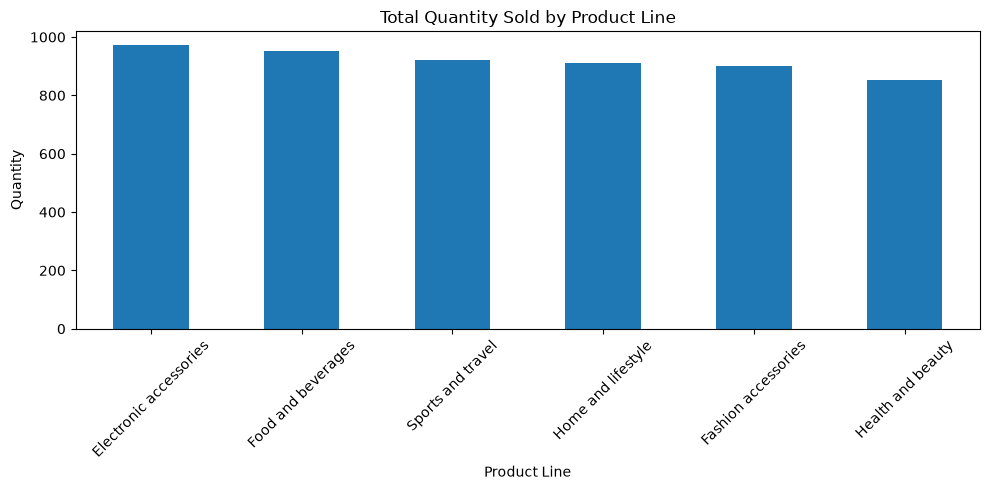

In [27]:
quantity_by_product = df.groupby("Product line")["Quantity"].sum().sort_values(ascending=False)

print(quantity_by_product)

plt.figure(figsize=(10, 5))

quantity_by_product.plot(kind="bar")

plt.title("Total Quantity Sold by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
numeric_data = df[[
    "Unit price",
    "Quantity",
    "Tax 5%",
    "Sales",
    "cogs",
    "gross margin percentage",
    "gross income",
    "Rating"
]]

correlation = numeric_data.corr()

print(correlation)

                         Unit price  Quantity    Tax 5%     Sales      cogs  \
Unit price                 1.000000  0.010778  0.633962  0.633962  0.633962   
Quantity                   0.010778  1.000000  0.705510  0.705510  0.705510   
Tax 5%                     0.633962  0.705510  1.000000  1.000000  1.000000   
Sales                      0.633962  0.705510  1.000000  1.000000  1.000000   
cogs                       0.633962  0.705510  1.000000  1.000000  1.000000   
gross margin percentage         NaN       NaN       NaN       NaN       NaN   
gross income               0.633962  0.705510  1.000000  1.000000  1.000000   
Rating                    -0.008778 -0.015815 -0.036442 -0.036442 -0.036442   

                         gross margin percentage  gross income    Rating  
Unit price                                   NaN      0.633962 -0.008778  
Quantity                                     NaN      0.705510 -0.015815  
Tax 5%                                       NaN      1.000000 

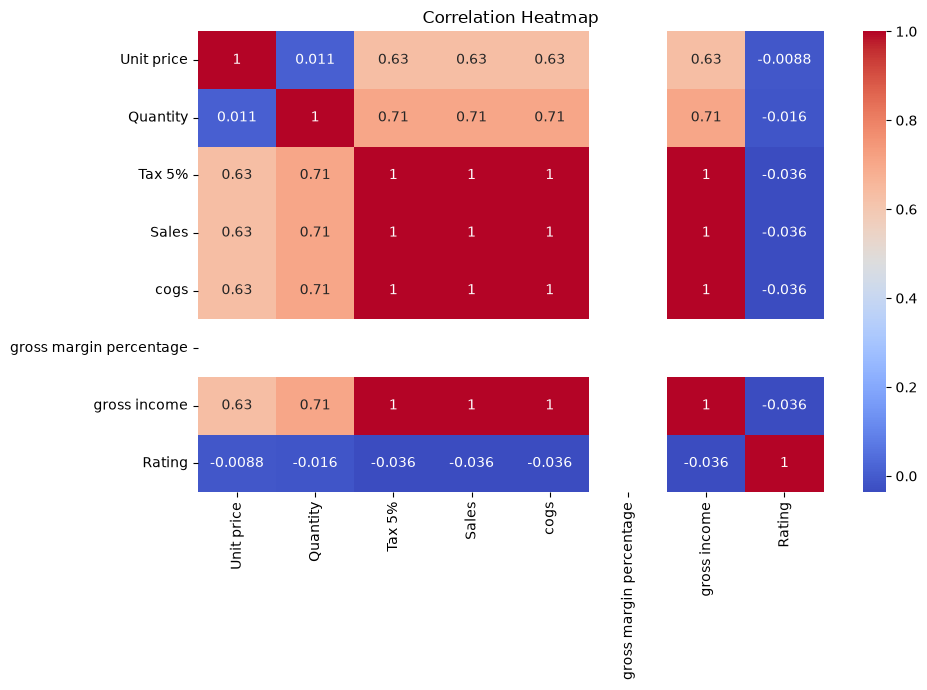

In [29]:
plt.figure(figsize=(10, 7))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [30]:
print("DATASET INSIGHTS")
print("----------------------------")

print("Total Sales:", df["Sales"].sum())
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Rating:", df["Rating"].mean())
print("Average Sales:", df["Sales"].mean())

print("\nBest Selling Product Line:")
print(sales_by_product.index[0])

print("\nBest Performing Branch:")
print(sales_by_branch.index[0])

print("\nMost Used Payment Method:")
print(df["Payment"].value_counts().index[0])

DATASET INSIGHTS
----------------------------
Total Sales: 322966.749
Total Quantity Sold: 5510
Average Rating: 6.9727
Average Sales: 322.966749

Best Selling Product Line:
Food and beverages

Best Performing Branch:
Giza

Most Used Payment Method:
Ewallet


In [31]:
print("EDA PROJECT - FINAL SUMMARY")
print("============================")

print("1. Total Records:", len(df))
print("2. Total Sales:", round(df["Sales"].sum(), 2))
print("3. Total Quantity Sold:", df["Quantity"].sum())
print("4. Average Sales:", round(df["Sales"].mean(), 2))
print("5. Average Rating:", round(df["Rating"].mean(), 2))

print("\nTop Product Line:")
print(sales_by_product.index[0])

print("\nBest Branch:")
print(sales_by_branch.index[0])

print("\nMost Popular Payment Method:")
print(df["Payment"].value_counts().index[0])

print("\nEDA Completed Successfully!")

EDA PROJECT - FINAL SUMMARY
1. Total Records: 1000
2. Total Sales: 322966.75
3. Total Quantity Sold: 5510
4. Average Sales: 322.97
5. Average Rating: 6.97

Top Product Line:
Food and beverages

Best Branch:
Giza

Most Popular Payment Method:
Ewallet

EDA Completed Successfully!


## Conclusion

The Exploratory Data Analysis (EDA) was successfully performed on the SuperMarket Sales dataset.

The dataset was analyzed using statistical summaries and visualizations. Important patterns were identified based on product lines, branches, payment methods, sales, quantity, and ratings.

EDA helped in understanding the dataset and identifying important factors that influence sales performance.

### Key Findings
- Identified the highest-selling product line.
- Compared sales across different branches.
- Analyzed popular payment methods.
- Studied sales and quantity distributions.
- Visualized relationships between important numerical variables.

Overall, this project improved understanding of data exploration, visualization, and analytical techniques using Python.